# G-CHAD New API: Collaborator Demo

This notebook gives a practical tour of the new API:
1. Build and run a detector online
2. Define a custom score model
3. Calibrate thresholds with Monte Carlo
4. Run a small simulation study of detection delay

## Imports

In [1]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold_false_alarm, mc_alarm_times
from gridcp.scores import MeanCUSUM
from gridcp.typing import ArrayLike

## 1) Online Detection with a Built-in Score

We first use the built-in `MeanCUSUM` score and a helper that runs the detector sequentially on a data stream.

In [2]:
def run_online_grid_detector(
    data: ArrayLike,
    detector: GridDetector,
    reset_on_alarm: bool = False,
) -> tuple[list, list[dict]]:
    """Run a configured GridDetector over a dataset sequentially."""
    data = np.asarray(data)
    state = detector.init_state()
    states = [state]
    outputs = []

    for x in data:
        state, output = detector.update(state, x)
        states.append(state)
        outputs.append(output)
        if output["alarm"] and reset_on_alarm:
            state = detector.init_state()

    return states, outputs

In [ ]:
rng = np.random.default_rng(42)
n_samples = 240
n_features = 1
true_cp = 120

data = np.concatenate(
    [
        rng.normal(loc=0.0, scale=1.0, size=(true_cp, n_features)),
        rng.normal(loc=2.0, scale=1.0, size=(n_samples - true_cp, n_features)),
    ]
)

detector = GridDetector(score=MeanCUSUM(n_features=n_features), threshold=3.5)
states, outputs = run_online_grid_detector(data, detector)

alarm_times = [o["n_samples"] for o in outputs if o["alarm"]]
first_alarm_sample_size = alarm_times[0] if alarm_times else None

print(f"True changepoint index (first post-change sample, 0-indexed): {true_cp}")
print(f"First alarm sample size (1-indexed): {first_alarm_sample_size}")
if first_alarm_sample_size is not None:
    print(f"First alarm index (0-indexed): {first_alarm_sample_size - 1}")

True changepoint index (first post-change sample, 0-indexed): 120
First alarm sample size (1-indexed): 125
First alarm index (0-indexed): 124


## 2) Custom Score Example: Univariate Mean Change With Unknown Variance

In Section 1 we used a built-in score model (`MeanCUSUM`). Here we show how to define a custom model by reproducing the *unknown-variance univariate mean-change* logic.

Important: this score is already implemented in `gridcp/scores/_mean_cusum_unknown_variance.py` and exported in `gridcp.scores` as `MeanCUSUMUnknownVariance`.
In practice, collaborators should usually import and use that built-in class directly.


### How `gridcp/typing.py` Guides Class Design

The key file is `gridcp/typing.py`, which defines:
- `TScoreState = TypeVar("TScoreState")`
- `class ScoreModel(Protocol[TScoreState])`

This means the detector expects any score class to follow a required interface (a protocol).
You do not need to explicitly inherit from `ScoreModel`; Python checks compatibility by structure (duck typing).

`ScoreModel` requires exactly these method shapes:
- `init_state(self) -> TScoreState`
- `update(self, state: TScoreState, x: ArrayLike) -> TScoreState`
- `compute_penalised_scores(self, state: TScoreState, grid_states: list[TScoreState]) -> np.ndarray`

How the demo class follows this:
- `TScoreState` is represented by `DemoUnknownVarUnivariateState`.
- `init_state` returns a fresh state with zero sufficient statistics.
- `update` takes one observation (`x`) and returns the updated state.
- `compute_penalised_scores` returns one score per active grid state (as a NumPy array).

Because `ScoreModel` is generic in `TScoreState`, each score implementation can define its own state container, as long as it is used consistently in all three methods.


### Typing Rules Used Here

The type hints are there to make the code easier to understand and safer to edit.
- Type hints in Python are guidance, not strict runtime enforcement by default.
- We still do runtime checks where needed (for example, checking `x_arr.size != 1`).
- `ArrayLike` is a convenient alias for inputs that can be converted to NumPy arrays.
- Numba-compiled functions (`@nb.njit`) still benefit from consistent input shapes and dtypes.

To avoid name clashes with built-in classes, everything below uses a `Demo...` prefix.

In [ ]:
import numba as nb


@nb.njit(cache=True)
def demo_unknown_var_univariate_raw_score(
    total_stats: np.ndarray,
    before_stats: np.ndarray,
    total_samples: int,
    before_samples: np.ndarray,
) -> np.ndarray:
    """Unknown-variance LR score for univariate mean change.

    This is a demo copy of the same statistical idea used by the built-in
    MeanCUSUMUnknownVariance score in gridcp/scores/.
    """
    n_candidates = before_samples.shape[0]
    out = np.zeros(n_candidates, dtype=np.float64)

    total_sum = total_stats[0]
    total_sum2 = total_stats[1]

    for i in range(n_candidates):
        n1 = before_samples[i]
        n2 = total_samples - n1

        # Match built-in small-sample behavior.
        if n1 <= 2 or n2 <= 2:
            out[i] = 0.0
            continue

        sum1 = before_stats[i, 0]
        sum2_1 = before_stats[i, 1]
        sum2 = total_sum - sum1
        sum2_2 = total_sum2 - sum2_1

        sigma_null = (
            total_sum2 - total_sum * total_sum / total_samples
        ) / total_samples
        sigma_alt = (
            (sum2_1 - sum1 * sum1 / n1) + (sum2_2 - sum2 * sum2 / n2)
        ) / total_samples

        if sigma_null <= 0.0 or sigma_alt <= 0.0:
            out[i] = 0.0
            continue

        lr = total_samples * np.log(sigma_null) - total_samples * np.log(sigma_alt)
        out[i] = lr - 1.0

    return out


@nb.njit(cache=True)
def demo_unknown_var_univariate_penalty(n_samples: int) -> float:
    logg = np.log(n_samples)
    return logg + np.sqrt(logg)


@dataclass(slots=True)
class DemoUnknownVarUnivariateState:
    """Running sufficient statistics [sum(x), sum(x^2)]."""

    n_samples: int = 0
    stats: np.ndarray = None


class DemoUnknownVarUnivariateScore:
    """Notebook-local demo score for unknown-variance univariate mean change.

    Prefer using the built-in `MeanCUSUMUnknownVariance` from `gridcp.scores`
    in production and paper code.
    """

    n_features = 1

    def init_state(self) -> DemoUnknownVarUnivariateState:
        return DemoUnknownVarUnivariateState(stats=np.zeros(2, dtype=np.float64))

    def update(
        self,
        state: DemoUnknownVarUnivariateState,
        x: ArrayLike,
    ) -> DemoUnknownVarUnivariateState:
        x_arr = np.asarray(x, dtype=np.float64).reshape(-1)
        if x_arr.size != 1:
            raise ValueError(
                f"DemoUnknownVarUnivariateScore expected one value, got {x_arr.size}."
            )

        val = float(x_arr[0])
        increment = np.array([val, val * val], dtype=np.float64)
        return DemoUnknownVarUnivariateState(
            n_samples=state.n_samples + 1,
            stats=state.stats + increment,
        )

    def compute_penalised_scores(
        self,
        state: DemoUnknownVarUnivariateState,
        grid_states: list[DemoUnknownVarUnivariateState],
        n_samples_for_penalty: int,
    ) -> np.ndarray:
        if len(grid_states) == 0:
            raise ValueError("grid_states is empty.")

        before_stats = np.stack([s.stats for s in grid_states])
        before_samples = np.array([s.n_samples for s in grid_states], dtype=np.int64)

        raw_scores = demo_unknown_var_univariate_raw_score(
            total_stats=state.stats,
            before_stats=before_stats,
            total_samples=state.n_samples,
            before_samples=before_samples,
        )
        penalty = demo_unknown_var_univariate_penalty(n_samples_for_penalty)
        return raw_scores / penalty

In [ ]:
demo_unknown_var_detector = GridDetector(
    score=DemoUnknownVarUnivariateScore(),
    threshold=3.5,
)
_, demo_unknown_var_outputs = run_online_grid_detector(data, demo_unknown_var_detector)
demo_unknown_var_alarm_times = [
    o["n_samples"] for o in demo_unknown_var_outputs if o["alarm"]
]

print(
    "Demo unknown-variance score first alarm (sample size, 1-indexed):",
    demo_unknown_var_alarm_times[0] if demo_unknown_var_alarm_times else None,
)

Demo unknown-variance score first alarm (sample size, 1-indexed): 124


## 3) Calibrating Critical Values (Thresholds) with Monte Carlo

We calibrate one threshold for each detector under the null (no change):
- known-variance detector (`MeanCUSUM`)
- unknown-variance demo detector (`DemoUnknownVarUnivariateScore`)

Then we estimate empirical false-alarm probabilities for both, using their own calibrated thresholds.

In [3]:
def normal_sampler(rng, size, loc, scale):
    return rng.normal(size=size, loc=loc, scale=scale)


stream_len = 150
n_paths_calibrate = 3000
n_paths_eval = 2000
n_features = 1
false_alarm_probability = 0.05

known_score = MeanCUSUM(n_features=n_features)
known_threshold = calibrate_threshold_false_alarm(
    score=known_score,
    false_alarm_probability=false_alarm_probability,
    stream_len=stream_len,
    n_paths=n_paths_calibrate,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=123,
    parallel=True,
    n_jobs=4,
)
known_detector = GridDetector(score=known_score, threshold=known_threshold)

demo_unknown_var_score = DemoUnknownVarUnivariateScore()
demo_unknown_var_threshold = calibrate_threshold_false_alarm(
    score=demo_unknown_var_score,
    false_alarm_probability=false_alarm_probability,
    stream_len=stream_len,
    n_paths=n_paths_calibrate,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=124,
    parallel=True,
    n_jobs=4,
)
demo_unknown_var_detector = GridDetector(
    score=demo_unknown_var_score,
    threshold=demo_unknown_var_threshold,
)

print(
    f"Known-variance threshold (false_alarm_probability={false_alarm_probability}): "
    f"{known_threshold:.4f}"
)
print(
    "Unknown-variance demo threshold "
    f"(false_alarm_probability={false_alarm_probability}): "
    f"{demo_unknown_var_threshold:.4f}"
)

Known-variance threshold (false_alarm_probability=0.05): 3.0453
Unknown-variance demo threshold (false_alarm_probability=0.05): 3.0271


In [10]:
known_null_alarm_times = mc_alarm_times(
    detector=known_detector,
    n_paths=n_paths_eval,
    stream_len=stream_len,
    n_features=n_features,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=2026,
    parallel=True,
    n_jobs=4,
)

unknown_null_alarm_times = mc_alarm_times(
    detector=demo_unknown_var_detector,
    n_paths=n_paths_eval,
    stream_len=stream_len,
    n_features=n_features,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=2026,
    parallel=True,
    n_jobs=4,
)

# mc_alarm_times returns 0-indexed alarm indices; no alarm in path => stream_len
known_fa_prob = np.mean(known_null_alarm_times < stream_len)
unknown_fa_prob = np.mean(unknown_null_alarm_times < stream_len)

print(f"Known-variance empirical false alarm probability: {known_fa_prob:.4f}")
print(
    "Unknown-variance demo empirical false alarm probability:",
    f"{unknown_fa_prob:.4f}",
)

Known-variance empirical false alarm probability: 0.0535
Unknown-variance demo empirical false alarm probability: 0.0530


## 4) Simple Simulation Study: Detection Delay vs Signal Strength

We vary the post-change mean and estimate average detection delay:
- changepoint is the **first post-change index** (0-indexed)
- alarm_time is the 0-indexed time at which an alarm is first raised
- delay = alarm_index - changepoint
- delay should ideally be as close to $0$ as possible, and not $1$
- paths with no alarm are counted as delay = stream_len - changepoint

In [8]:
post_change_mus = np.linspace(0.0, 4.0, num=15)
changepoint = stream_len // 2
mean_delays_known = []
mean_delays_unknown = []

for mu in post_change_mus:
    known_alarm_times = mc_alarm_times(
        detector=known_detector,
        n_paths=n_paths_eval,
        stream_len=stream_len,
        n_features=n_features,
        pre_sampler=normal_sampler,
        pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
        post_sampler=normal_sampler,
        post_kwargs={"size": n_features, "loc": float(mu), "scale": 1.0},
        changepoint=changepoint,
        rng=2027,
        parallel=True,
        n_jobs=4,
    )
    known_delay = known_alarm_times - changepoint
    known_delay = known_delay[known_delay >= 0]
    mean_delays_known.append(float(np.mean(known_delay)))

    unknown_alarm_times = mc_alarm_times(
        detector=demo_unknown_var_detector,
        n_paths=n_paths_eval,
        stream_len=stream_len,
        n_features=n_features,
        pre_sampler=normal_sampler,
        pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
        post_sampler=normal_sampler,
        post_kwargs={"size": n_features, "loc": float(mu), "scale": 1.0},
        changepoint=changepoint,
        rng=3027,
        parallel=True,
        n_jobs=4,
    )
    unknown_delay = unknown_alarm_times - changepoint
    unknown_delay = unknown_delay[unknown_delay >= 0]
    mean_delays_unknown.append(float(np.mean(unknown_delay)))

mean_delays_known = np.asarray(mean_delays_known)
mean_delays_unknown = np.asarray(mean_delays_unknown)

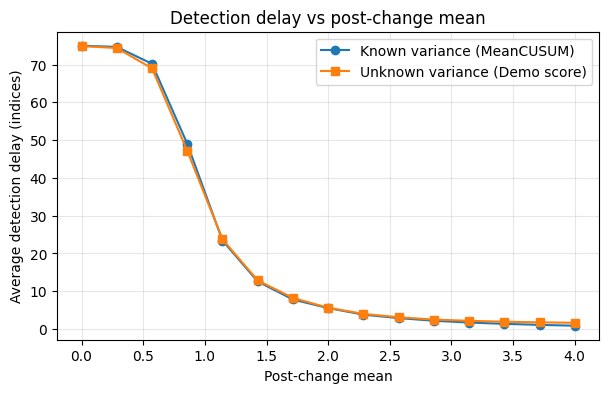

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(
    post_change_mus,
    mean_delays_known,
    marker="o",
    label="Known variance (MeanCUSUM)",
)
plt.plot(
    post_change_mus,
    mean_delays_unknown,
    marker="s",
    label="Unknown variance (Demo score)",
)
plt.xlabel("Post-change mean")
plt.ylabel("Average detection delay (indices)")
plt.title("Detection delay vs post-change mean")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Notes 

- Internal detector counters often represent sample size (`t=1,2,...`).
- Public Monte Carlo outputs (for example `mc_alarm_times`) use 0-indexed indices.
- `changepoint` can be an `int` or a callable `f(rng, stream_len, path_idx) -> int`;
  if path-specific behavior is not needed, ignore `path_idx`.